# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [56]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [57]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset

print("=== Heart Disease Dataset ===")
print(f"X shape: {X_clf.shape}, y shape: {y_clf.shape}")
print(f"Missing values:\n{X_clf.isnull().sum()}")
print(X_clf.describe())
 
print("\n=== Aging Dataset ===")
age = df_aging["age"]
methylation_df = df_aging.drop(columns=["age"])
print(f"Methylation shape: {methylation_df.shape}")
print(f"Missing values (total): {methylation_df.isnull().sum().sum()}")
print(f"Age target — min: {age.min():.1f}, max: {age.max():.1f}, mean: {age.mean():.1f}")


Successfully loaded heart disease data with 1025 rows
=== Heart Disease Dataset ===
X shape: (1025, 13), y shape: (1025,)
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

         

c:\Users\Jonathan Xu\Documents\CS_CLASSES\CSCI1851\homework-3-generoussidewalk\src\hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


Missing values (total): 526
Age target — min: 65.0, max: 94.0, mean: 73.0


## Classification Task (Heart Disease)

Exploring classification dataset...


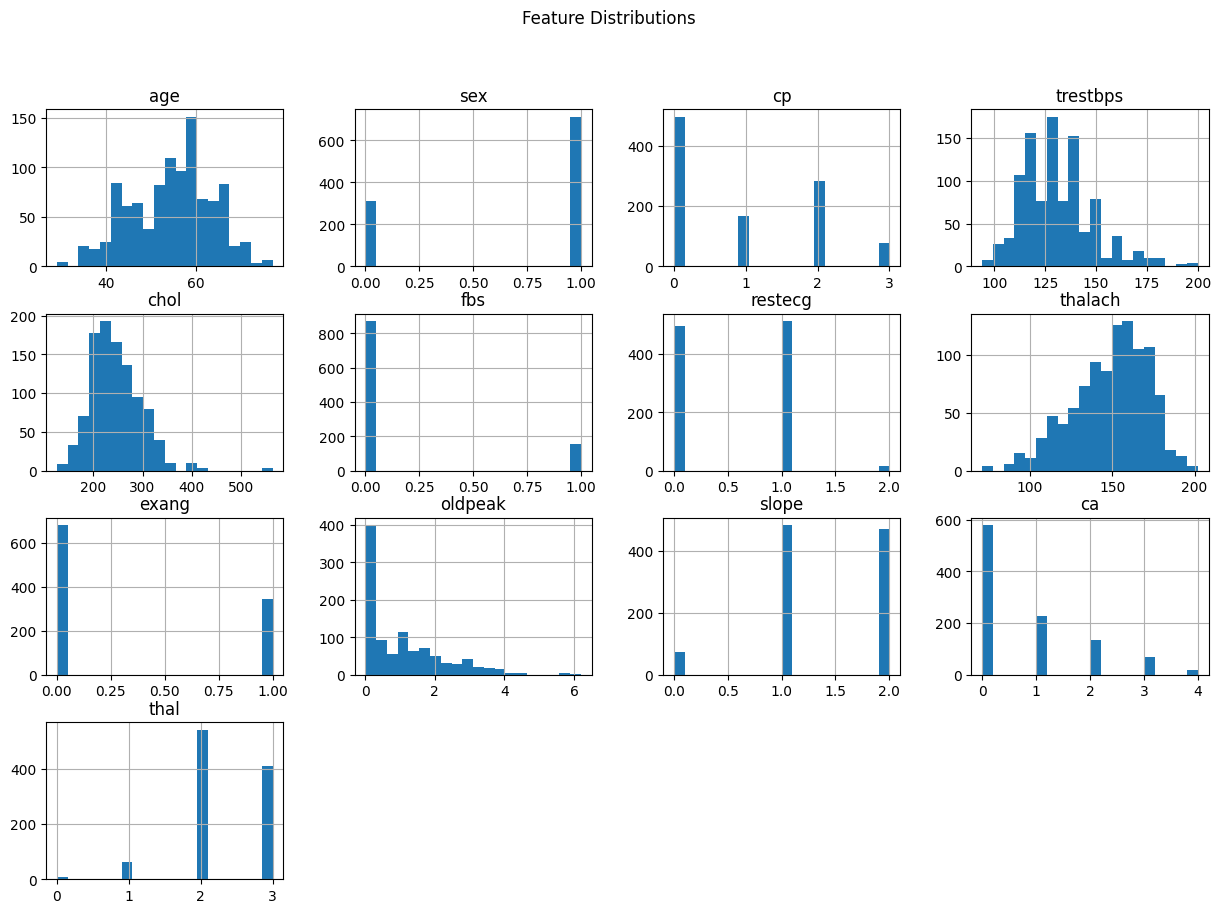

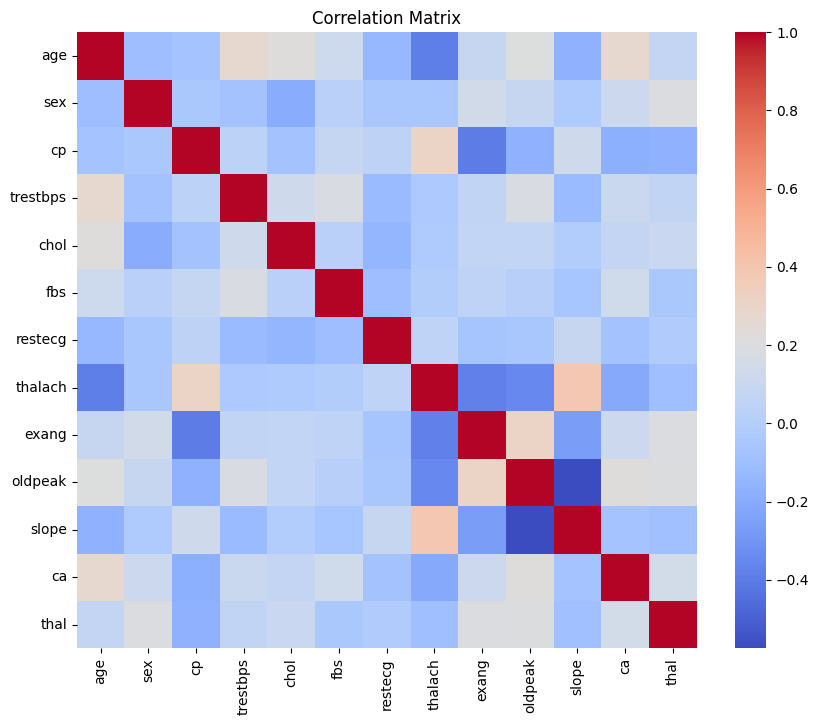

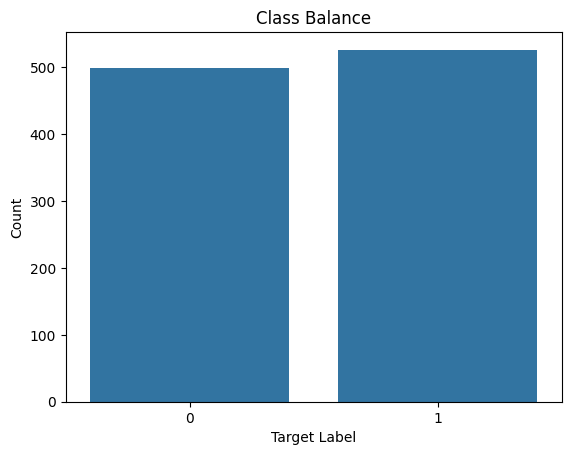

In [58]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)

In [59]:
# TODO: Split X_clf and y_clf into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train_clf, X_test_clf, y_train_clf, y_test_clf =train_test_split(
    X_clf, y_clf,test_size=0.2, random_state=42, stratify=y_clf
)
print(f"\nClassification — train: {X_train_clf.shape}, test: {X_test_clf.shape}")


Classification — train: (820, 13), test: (205, 13)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [60]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])
clf_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    # ("pca", PCA(n_components=10)),   # optional — uncomment to add PCA
    ("model",   svm_classifier(kernel="rbf", C=1.0,gamma="scale")),
])
clf_pipeline.fit(X_train_clf, y_train_clf)
print("Classification pipeline (RBF baseline) trained.")

Classification pipeline (RBF baseline) trained.


### Kernel Experiments

In [61]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
kernel_configs = [
    {"kernel": "linear", "C": 1.0},
    {"kernel": "poly",   "C": 1.0, "degree": 2, "gamma": "scale"},
    {"kernel": "poly",   "C": 1.0, "degree": 3, "gamma": "scale"},
    {"kernel": "poly",   "C": 1.0, "degree": 4, "gamma": "scale"},
    {"kernel": "rbf",    "C": 1.0, "gamma": 0.01},
    {"kernel": "rbf",    "C": 1.0, "gamma": 0.1},
    {"kernel": "rbf",    "C": 1.0, "gamma": "scale"},
]
 
clf_results = {}
best_clf_pipeline = None
best_clf_f1 = -1
best_clf_kernel = None
 
print("\n--- Kernel Experiments (Classification) ---")
for cfg in kernel_configs:
    kernel = cfg["kernel"]
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model",   svm_classifier(**cfg)),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    metrics = evaluate_classifier(pipe, X_test_clf, y_test_clf)
    clf_results[str(cfg)] = metrics
    label = f"kernel={kernel:6s}"
    if "degree" in cfg: label += f" degree={cfg['degree']}"
    if "gamma"  in cfg and cfg["gamma"] != "scale": label += f" gamma={cfg['gamma']}"
    print(
        f"  {label} | acc={metrics['accuracy']:.4f} | "
        f"f1={metrics['f1']:.4f} | prec={metrics['precision']:.4f} | "
        f"rec={metrics['recall']:.4f}"
    )
    if metrics["f1"] > best_clf_f1:
        best_clf_f1 = metrics["f1"]
        best_clf_pipeline =pipe
        best_clf_kernel = kernel
        best_clf_cfg =cfg
 
print(f"\nBest config: {best_clf_cfg}  (F1 = {best_clf_f1:.4f})")


--- Kernel Experiments (Classification) ---
  kernel=linear | acc=0.8146 | f1=0.8120 | prec=0.8290 | rec=0.8146
  kernel=poly   degree=2 | acc=0.7707 | f1=0.7703 | prec=0.7716 | rec=0.7707
  kernel=poly   degree=3 | acc=0.9268 | f1=0.9266 | prec=0.9300 | rec=0.9268
  kernel=poly   degree=4 | acc=0.8780 | f1=0.8772 | prec=0.8859 | rec=0.8780
  kernel=rbf    gamma=0.01 | acc=0.8000 | f1=0.7969 | prec=0.8149 | rec=0.8000
  kernel=rbf    gamma=0.1 | acc=0.9512 | f1=0.9512 | prec=0.9519 | rec=0.9512
  kernel=rbf    | acc=0.9268 | f1=0.9268 | prec=0.9271 | rec=0.9268

Best config: {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1}  (F1 = 0.9512)


### Classification Metrics and Visuals


Final metrics — Accuracy: 0.9512 | F1: 0.9512 | ROC-AUC: 0.9806


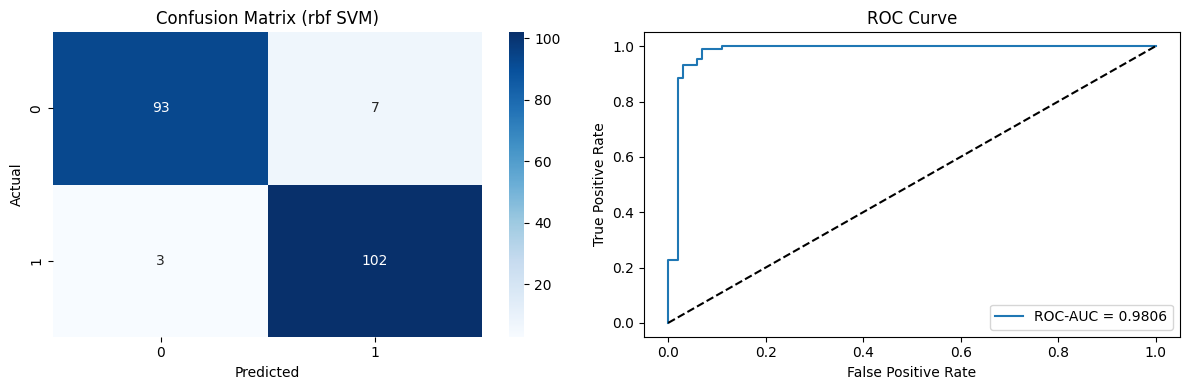

In [62]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve
y_pred_clf =best_clf_pipeline.predict(X_test_clf)
y_prob_clf =best_clf_pipeline.predict_proba(X_test_clf)[:, 1]
 
acc = accuracy_score(y_test_clf, y_pred_clf)
f1  = f1_score(y_test_clf, y_pred_clf, average="weighted")
auc = roc_auc_score(y_test_clf, y_prob_clf)
print(f"\nFinal metrics — Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
cm =confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix ({best_clf_kernel} SVM)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
 
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("clf_metrics.png",dpi=150)
plt.show()

### Hyperparameter Sensitivity

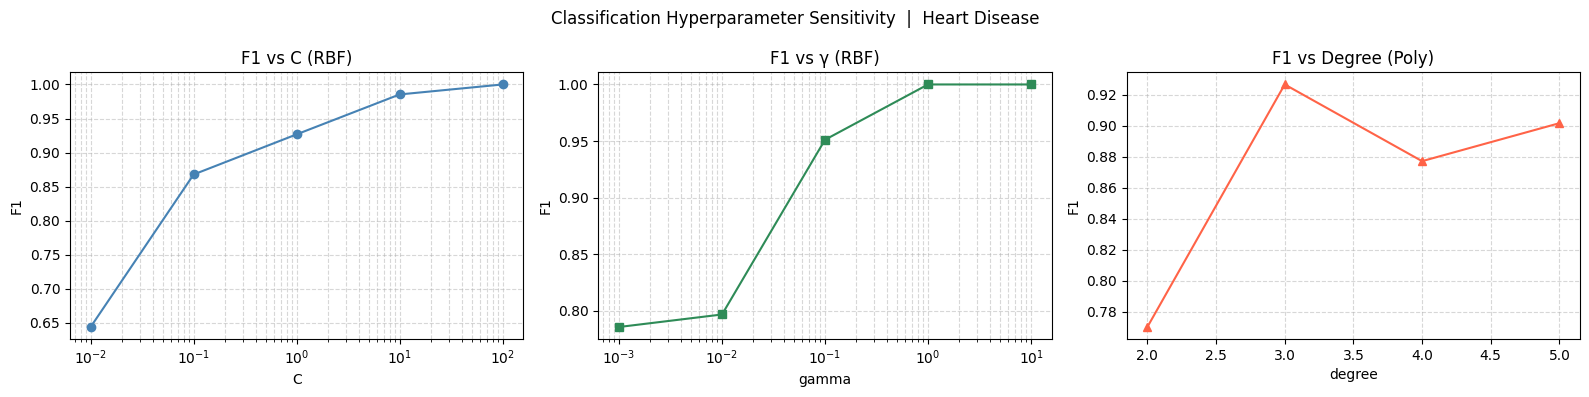

In [63]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
C_values = [0.01, 0.1, 1, 10,100]
f1_vs_C = []
 
for C in C_values:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   svm_classifier(kernel="rbf", C=C, gamma="scale")),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    metrics = evaluate_classifier(pipe, X_test_clf, y_test_clf)
    f1_vs_C.append(metrics["f1"])
 
gamma_values = [0.001,0.01, 0.1, 1, 10]
f1_vs_gamma = []
for g in gamma_values:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   svm_classifier(kernel="rbf", C=1.0, gamma=g)),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    f1_vs_gamma.append(evaluate_classifier(pipe, X_test_clf, y_test_clf)["f1"])
 
degrees = [2, 3, 4, 5]
f1_vs_degree = []
for d in degrees:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   svm_classifier(kernel="poly", C=1.0, degree=d, gamma="scale")),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    f1_vs_degree.append(evaluate_classifier(pipe, X_test_clf, y_test_clf)["f1"])
 
fig, axes = plt.subplots(1, 3,figsize=(16, 4))
 
axes[0].semilogx(C_values, f1_vs_C, marker="o", color="steelblue")
axes[0].set_xlabel("C"); axes[0].set_ylabel("F1"); axes[0].set_title("F1 vs C (RBF)")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
 
axes[1].semilogx(gamma_values, f1_vs_gamma, marker="s", color="seagreen")
axes[1].set_xlabel("gamma"); axes[1].set_ylabel("F1"); axes[1].set_title("F1 vs γ (RBF)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
 
axes[2].plot(degrees, f1_vs_degree, marker="^", color="tomato")
axes[2].set_xlabel("degree"); axes[2].set_ylabel("F1"); axes[2].set_title("F1 vs Degree (Poly)")
axes[2].grid(True, linestyle="--", alpha=0.5)
 
plt.suptitle("Classification Hyperparameter Sensitivity  |  Heart Disease")
plt.tight_layout()
plt.savefig("clf_sensitivity.png", dpi=150)
plt.show()


## Regression Task (Biological Aging)

In [64]:
# TODO: Separate target column "target" from features
# X_reg = df_aging.drop(columns=["target"])
# y_reg = df_aging["target"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
# imputer = SimpleImputer(strategy="mean")
# X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# TODO: Split X_reg and y_reg into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)

X_reg = df_aging.drop(columns=["age"])
y_reg = df_aging["age"]

X_reg = X_reg.select_dtypes(include=[np.number])
X_reg = X_reg.dropna(axis=1, how="all")
imputer_reg =  SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(
    imputer_reg.fit_transform(X_reg),
    columns=X_reg.columns,
)
 
X_train_reg,X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"\nRegression — train: {X_train_reg.shape}, test: {X_test_reg.shape}")



Regression — train: (29, 485511), test: (8, 485511)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [65]:
# TODO: Build a leakage-free pipeline for regression
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_regressor(kernel=..., C=..., degree=..., gamma=...)),
# ])
n_pca = min(X_train_reg.shape[0], X_train_reg.shape[1], 50)
reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ("pca",     PCA(n_components=n_pca)),
    ("model",   svm_regressor(kernel="rbf", C=1.0, gamma="scale")),
])
reg_pipeline.fit(X_train_reg, y_train_reg)
print("Regression pipeline (RBF + PCA-50 baseline) trained.")

Regression pipeline (RBF + PCA-50 baseline) trained.


### Kernel Experiments

In [66]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
reg_kernel_configs = [
    {"kernel": "linear", "C": 1.0},
    {"kernel": "poly",   "C": 1.0, "degree": 2, "gamma": "scale"},
    {"kernel": "poly",   "C": 1.0, "degree": 3, "gamma": "scale"},
    {"kernel": "poly",   "C": 1.0, "degree": 4, "gamma": "scale"},
    {"kernel": "rbf",    "C": 1.0, "gamma": 0.01},
    {"kernel": "rbf",    "C": 1.0, "gamma": 0.1},
    {"kernel": "rbf",    "C": 1.0, "gamma": "scale"},
]
 
reg_results = {}
best_reg_pipeline =None
best_reg_r2 = -np.inf
best_reg_kernel = None
best_reg_cfg = None
 
print("\n--- Kernel Experiments (Regression) ---")
for cfg in reg_kernel_configs:
    kernel = cfg["kernel"]
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("pca",     PCA(n_components=n_pca)),
        ("model",   svm_regressor(**cfg)),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    metrics = evaluate_regressor(pipe, X_test_reg, y_test_reg)
    reg_results[str(cfg)] = metrics
    label = f"kernel={kernel:6s}"
    if "degree" in cfg: label += f" degree={cfg['degree']}"
    if "gamma"  in cfg and cfg["gamma"] != "scale": label += f" gamma={cfg['gamma']}"
    print(
        f"  {label} | MAE={metrics['mae']:.3f} | "
        f"RMSE={metrics['rmse']:.3f} | R\u00b2={metrics['r2']:.4f}"
    )
    if metrics["r2"] > best_reg_r2:
        best_reg_r2 = metrics["r2"]
        best_reg_pipeline =pipe
        best_reg_kernel = kernel
        best_reg_cfg = cfg
 
print(f"\nBest config: {best_reg_cfg}  (R\u00b2 = {best_reg_r2:.4f})")


--- Kernel Experiments (Regression) ---
  kernel=linear | MAE=5.826 | RMSE=6.465 | R²=-0.2868
  kernel=poly   degree=2 | MAE=4.143 | RMSE=5.731 | R²=-0.0110
  kernel=poly   degree=3 | MAE=4.115 | RMSE=5.700 | R²=-0.0000
  kernel=poly   degree=4 | MAE=4.114 | RMSE=5.696 | R²=0.0014
  kernel=rbf    gamma=0.01 | MAE=4.238 | RMSE=5.700 | R²=-0.0003
  kernel=rbf    gamma=0.1 | MAE=4.238 | RMSE=5.700 | R²=-0.0003
  kernel=rbf    | MAE=4.239 | RMSE=5.706 | R²=-0.0023

Best config: {'kernel': 'poly', 'C': 1.0, 'degree': 4, 'gamma': 'scale'}  (R² = 0.0014)


### Regression Metrics and Visuals

In [67]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
# plot_regression_results(...)
# plot_residuals(...)
y_pred_reg =best_reg_pipeline.predict(X_test_reg)
 
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)
print(f"\nFinal metrics — MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.4f}")
 
plot_regression_results(
    y_test_reg, y_pred_reg,
    filename="reg_parity.png",
    title=f"Predicted vs Actual Age  ({best_reg_kernel} SVR + PCA-50)"
)
 
plot_residuals(
    y_test_reg, y_pred_reg,
    filename="reg_residuals.png",
    title=f"Residuals  ({best_reg_kernel} SVR + PCA-50)"
)


Final metrics — MAE: 4.114 | RMSE: 5.696 | R²: 0.0014


### Hyperparameter Sensitivity (Regression)

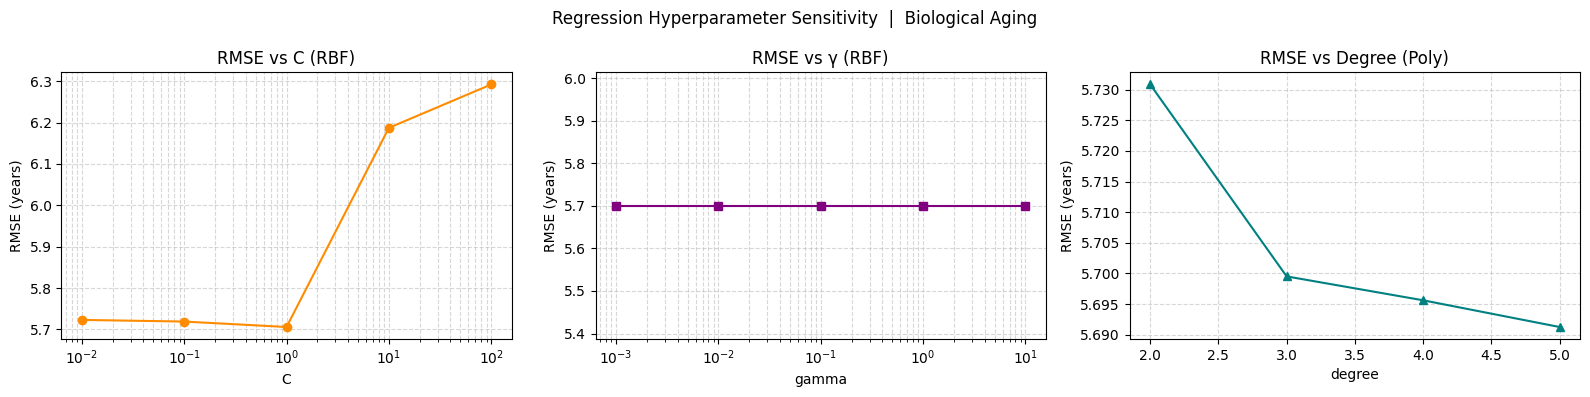


Outputs saved: clf_metrics.png, clf_C_sensitivity.png, reg_parity.png, reg_residuals.png, reg_C_sensitivity.png


In [68]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
C_values_reg = [0.01, 0.1, 1, 10, 100]
gamma_values_reg = [0.001, 0.01, 0.1, 1, 10]
degrees_reg = [2, 3, 4, 5]
 
# RMSE vs C (RBF)
rmse_vs_C = []
for C in C_values_reg:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("pca",     PCA(n_components=n_pca)),
        ("model",  svm_regressor(kernel="rbf", C=C, gamma="scale")),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    rmse_vs_C.append(evaluate_regressor(pipe, X_test_reg, y_test_reg)["rmse"])
 
# RMSE vs gamma (RBF, C=1)
rmse_vs_gamma = []
for g in gamma_values_reg:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("pca",     PCA(n_components=n_pca)),
        ("model",   svm_regressor(kernel="rbf", C=1.0, gamma=g)),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    rmse_vs_gamma.append(evaluate_regressor(pipe, X_test_reg, y_test_reg)["rmse"])

rmse_vs_degree = []
for d in degrees_reg:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("pca",     PCA(n_components=n_pca)),
        ("model",   svm_regressor(kernel="poly", C=1.0, degree=d, gamma="scale")),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    rmse_vs_degree.append(evaluate_regressor(pipe, X_test_reg, y_test_reg)["rmse"])
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
axes[0].semilogx(C_values_reg, rmse_vs_C, marker="o", color="darkorange")
axes[0].set_xlabel("C"); axes[0].set_ylabel("RMSE (years)");axes[0].set_title("RMSE vs C (RBF)")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
 
axes[1].semilogx(gamma_values_reg, rmse_vs_gamma, marker="s", color="purple")
axes[1].set_xlabel("gamma"); axes[1].set_ylabel("RMSE (years)"); axes[1].set_title("RMSE vs γ (RBF)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
 
axes[2].plot(degrees_reg,rmse_vs_degree, marker="^", color="teal")
axes[2].set_xlabel("degree"); axes[2].set_ylabel("RMSE (years)"); axes[2].set_title("RMSE vs Degree (Poly)")
axes[2].grid(True, linestyle="--", alpha=0.5)
 
plt.suptitle("Regression Hyperparameter Sensitivity  |  Biological Aging")
plt.tight_layout()
plt.savefig("reg_sensitivity.png", dpi=150)
plt.show()
 
print("\nOutputs saved: clf_metrics.png, clf_C_sensitivity.png, "
      "reg_parity.png, reg_residuals.png, reg_C_sensitivity.png")